In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
alarms_path = Path("data/alarms/alarms-240222-010325.csv")
alarms_raw = pd.read_csv(alarms_path, sep=";")
alarms = alarms_raw.copy()

In [16]:
alarms['start'] = pd.to_datetime(alarms['start'])
alarms['end'] = pd.to_datetime(alarms['end'])
alarms['duration_min'] = (alarms['end'] - alarms['start']).dt.total_seconds() / 60
alarms['start_hour'] = alarms['start'].dt.hour
alarms['day_of_week'] = alarms['start'].dt.day_name()

alarms = alarms.drop_duplicates()
alarms = alarms[(alarms['duration_min'] > 0)]

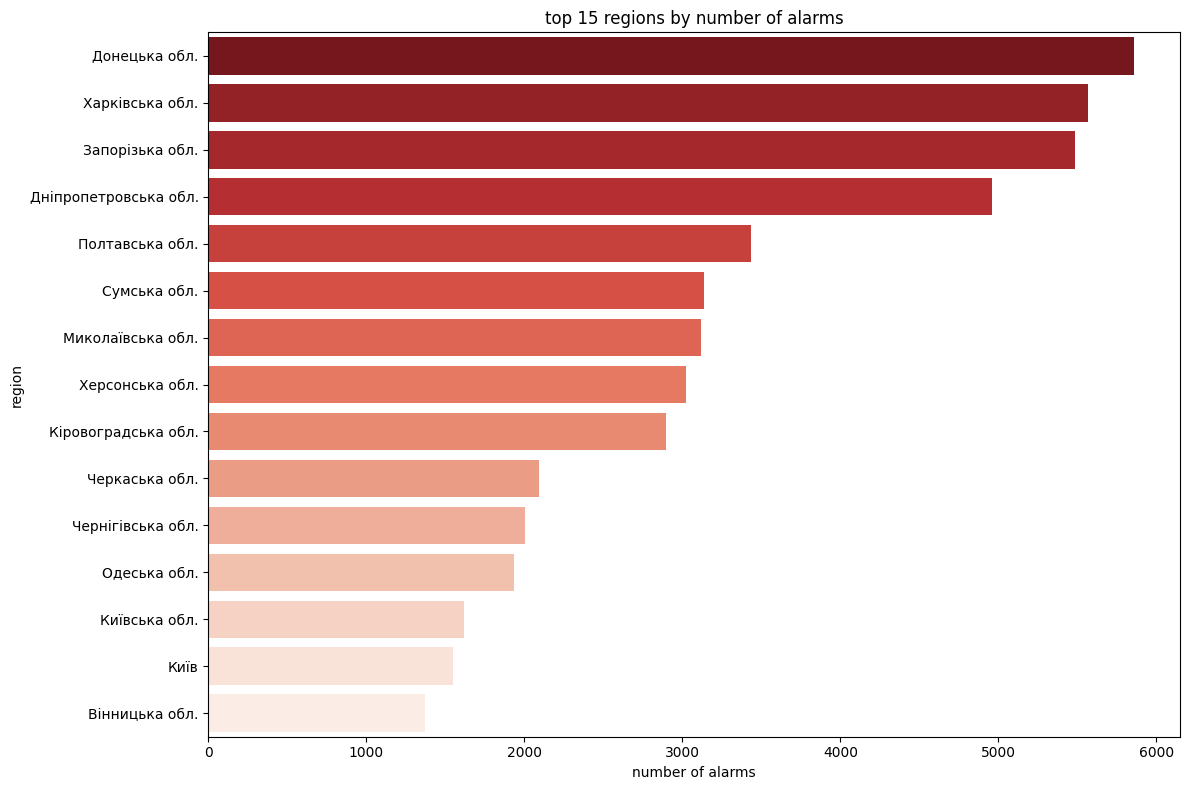

In [17]:
plt.figure(figsize=(12, 8))
alarms_by_region = alarms['region_city'].value_counts().head(15)

sns.barplot(x=alarms_by_region.values, y=alarms_by_region.index, palette='Reds_r', hue=alarms_by_region.index, legend=False)
plt.title('top 15 regions by number of alarms')
plt.xlabel('number of alarms')
plt.ylabel('region')

plt.tight_layout()
plt.show()

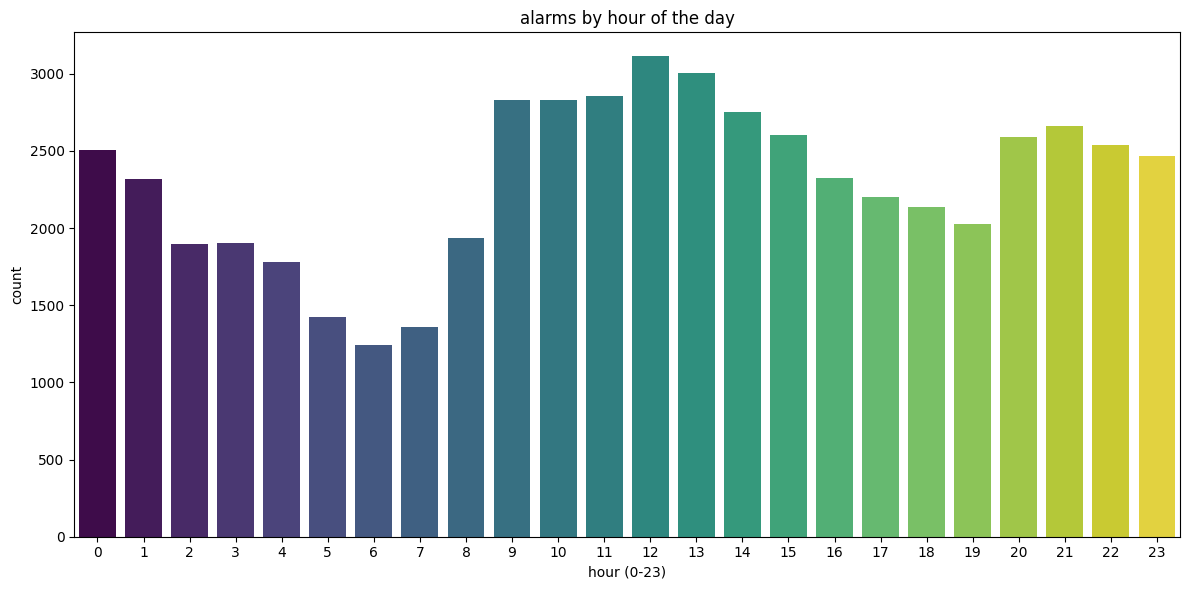

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(data=alarms, x='start_hour', palette='viridis', hue='start_hour', legend=False)

plt.title('alarms by hour of the day')
plt.xlabel('hour (0-23)')
plt.ylabel('count')

plt.tight_layout()
plt.show()

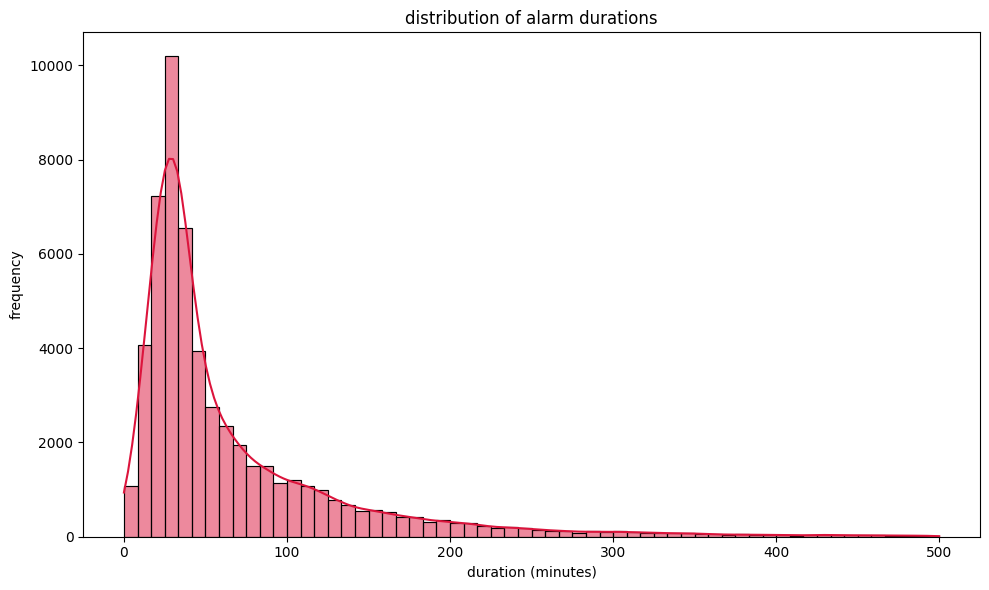

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(alarms['duration_min'], bins=60, kde=True, color='crimson')

plt.title('distribution of alarm durations')
plt.xlabel('duration (minutes)')
plt.ylabel('frequency')

plt.tight_layout()
plt.show()

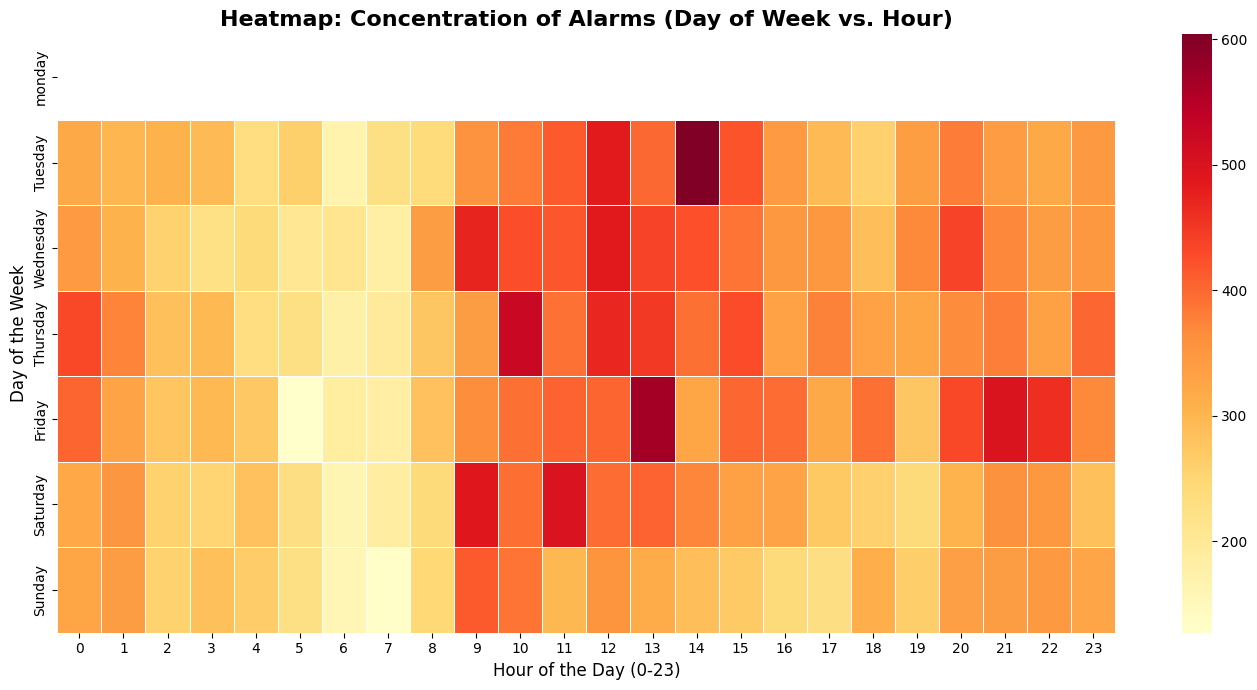

In [ ]:
plt.figure(figsize=(14, 7))
pivot_alarms = alarms.pivot_table(index='day_of_week', columns='start_hour', aggfunc='size', fill_value=0)
days_order = ['monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_alarms = pivot_alarms.reindex(days_order)

sns.heatmap(pivot_alarms, cmap='YlOrRd', linewidths=.5, annot=False)
plt.title('Heatmap: Concentration of Alarms (Day of Week vs. Hour)')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)

plt.tight_layout()
plt.show()